In [1]:
#INSTALL & IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import warnings
import ast
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print("✅ All libraries imported!")

✅ All libraries imported!


In [3]:
#LOAD DATASET

In [4]:
movies  = pd.read_csv("tmdb_5000_movies.csv")
credits = pd.read_csv("tmdb_5000_credits.csv")

print(f"Movies  shape : {movies.shape}")
print(f"Credits shape : {credits.shape}")
movies.head(2)

Movies  shape : (4803, 20)
Credits shape : (4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500


In [5]:
#MERGE DATASETS 

In [6]:
credits.rename(columns={'movie_id': 'id'}, inplace=True)
df = movies.merge(credits, on='id', how='left')

In [7]:
# Drop duplicate title column if present

In [8]:
if 'title_y' in df.columns:
    df.drop(columns=['title_y'], inplace=True)
    df.rename(columns={'title_x': 'title'}, inplace=True)

print(f"Merged dataset shape: {df.shape}")
print("Columns:", df.columns.tolist())

Merged dataset shape: (4803, 22)
Columns: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'cast', 'crew']


In [9]:
#HELPER FUNCTIONS TO PARSE JSON COLUMNS

In [10]:
def parse_names(json_str, key='name', limit=None):
    """Extract names from a JSON-like string column."""
    try:
        items = ast.literal_eval(str(json_str))
        names = [item[key] for item in items if key in item]
        return names[:limit] if limit else names
    except:
        return []

def get_director(crew_json):
    """Extract director name from crew JSON."""
    try:
        crew = ast.literal_eval(str(crew_json))
        for member in crew:
            if member.get('job') == 'Director':
                return member.get('name', '')
        return ''
    except:
        return ''

def collapse(lst):
    """Convert list to lowercase no-space string for TF-IDF."""
    return [str(x).lower().replace(' ', '') for x in lst]

In [11]:
# Apply parsing

In [12]:
df['genres_list']     = df['genres'].apply(lambda x: parse_names(x))
df['keywords_list']   = df['keywords'].apply(lambda x: parse_names(x))
df['cast_list']       = df['cast'].apply(lambda x: parse_names(x, limit=5))
df['director']        = df['crew'].apply(get_director)

print("✅ JSON columns parsed!")
print("\nSample genres:", df['genres_list'].iloc[0])
print("Sample cast  :", df['cast_list'].iloc[0])
print("Director     :", df['director'].iloc[0])

✅ JSON columns parsed!

Sample genres: ['Action', 'Adventure', 'Fantasy', 'Science Fiction']
Sample cast  : ['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver', 'Stephen Lang', 'Michelle Rodriguez']
Director     : James Cameron


In [13]:
#EXPLORATORY DATA ANALYSIS (EDA)

In [16]:
df['release_date'] = df['release_date'].astype(str).replace('nan', '')
valid_years = df['release_date'].str[:4].replace('', pd.NA).dropna()

print("\n" + "="*55)
print("         DATASET OVERVIEW")
print("="*55)
print(f"  Total Movies        : {len(df)}")
print(f"  Movies with votes   : {(df['vote_count'] > 0).sum()}")
print(f"  Average Rating      : {df['vote_average'].mean():.2f}")
print(f"  Year Range          : {df['release_date'].str[:4].min()} - {df['release_date'].str[:4].max()}")
print(f"  Missing Overviews   : {df['overview'].isnull().sum()}")
print("="*55)
print("\n🔍 Missing Values:")
print(df[['title','overview','genres','keywords','cast','crew','vote_average','popularity']].isnull().sum())


         DATASET OVERVIEW
  Total Movies        : 4803
  Movies with votes   : 4741
  Average Rating      : 6.09
  Year Range          :  - 2017
  Missing Overviews   : 3

🔍 Missing Values:
title           0
overview        3
genres          0
keywords        0
cast            0
crew            0
vote_average    0
popularity      0
dtype: int64


In [17]:
# EDA PLOTS

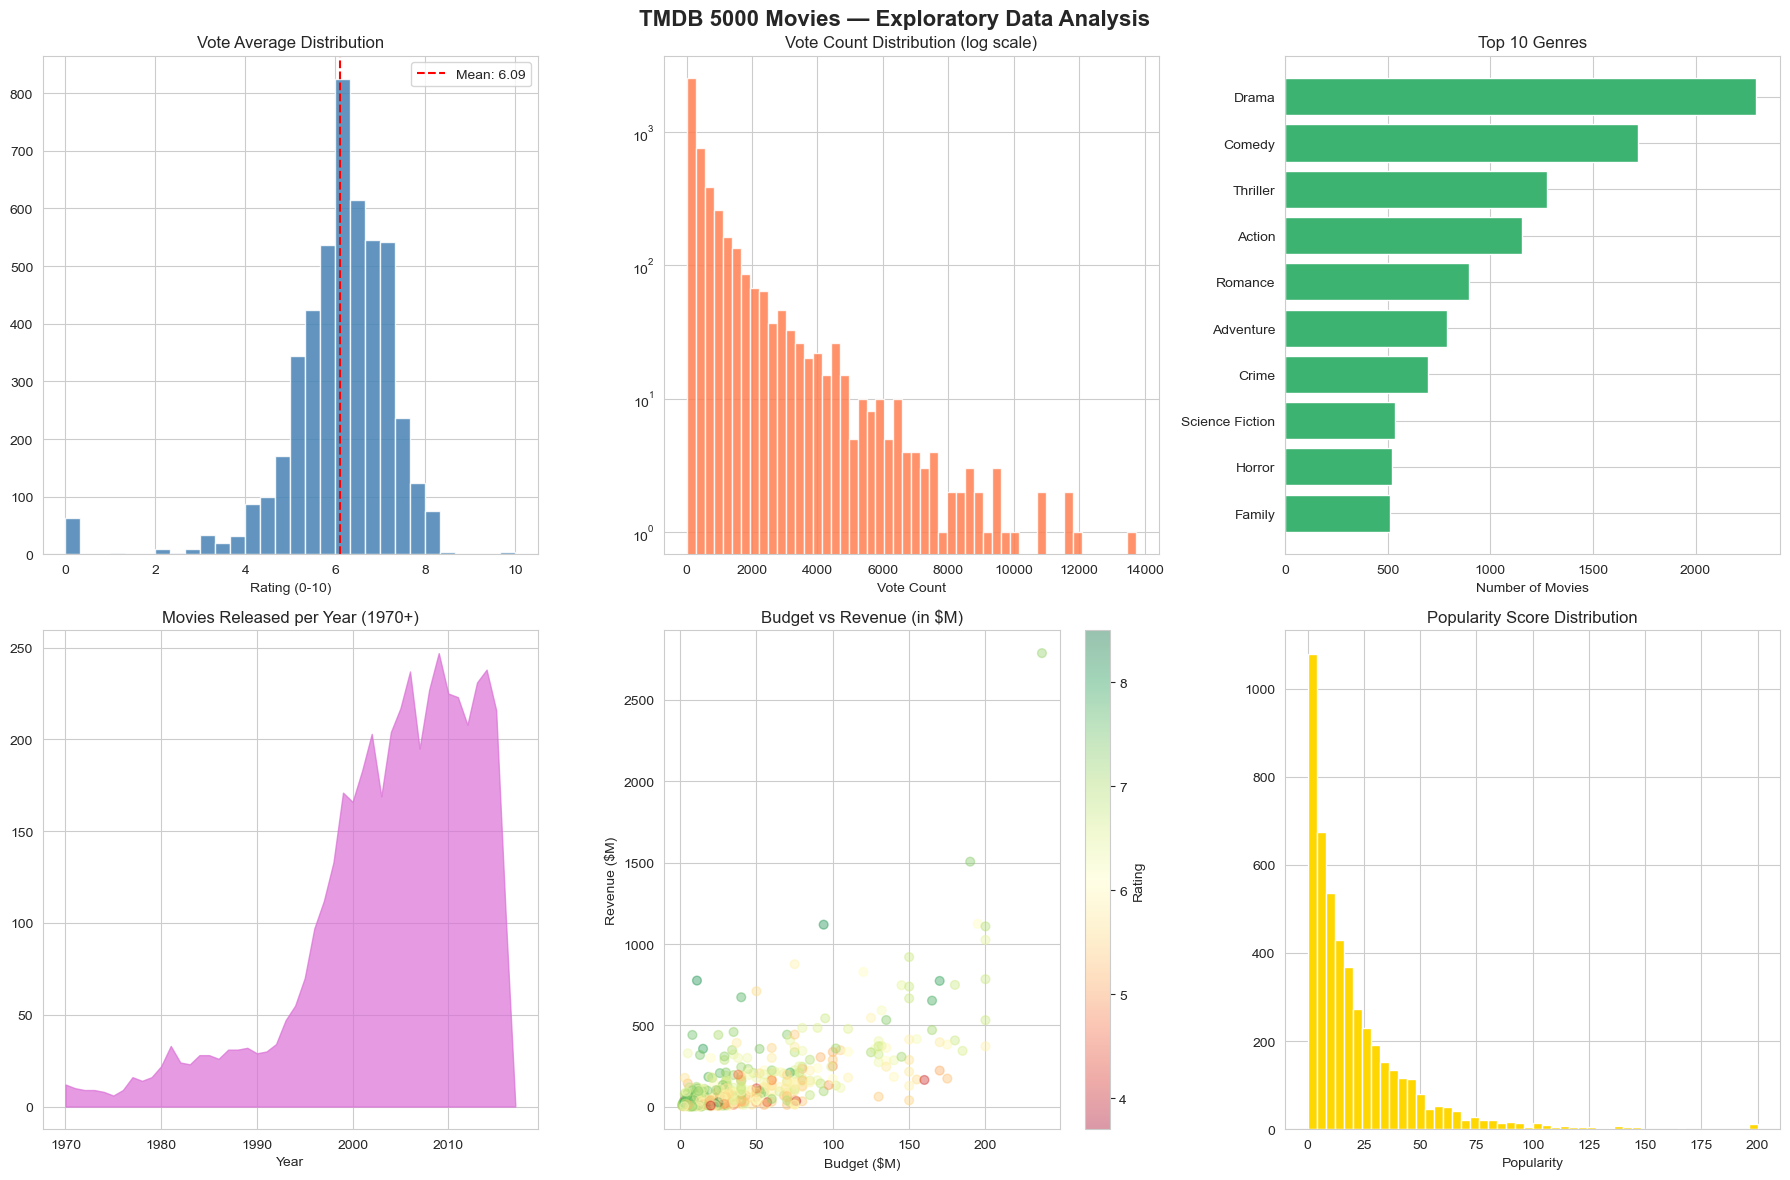

✅ EDA plots saved as eda_tmdb.png


In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('TMDB 5000 Movies — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1. Rating Distribution
axes[0,0].hist(df['vote_average'].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['vote_average'].mean(), color='red', linestyle='--',
                  label=f"Mean: {df['vote_average'].mean():.2f}")
axes[0,0].set_title('Vote Average Distribution')
axes[0,0].set_xlabel('Rating (0-10)')
axes[0,0].legend()

# 2. Vote Count Distribution 
axes[0,1].hist(df['vote_count'].dropna(), bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[0,1].set_yscale('log')
axes[0,1].set_title('Vote Count Distribution (log scale)')
axes[0,1].set_xlabel('Vote Count')

# 3. Top 10 Genres
all_genres = []
for g in df['genres_list']:
    all_genres.extend(g)
genre_counts = pd.Series(all_genres).value_counts().head(10)
axes[0,2].barh(genre_counts.index[::-1], genre_counts.values[::-1], color='mediumseagreen')
axes[0,2].set_title('Top 10 Genres')
axes[0,2].set_xlabel('Number of Movies')

# 4. Movies per Year
df['year'] = pd.to_numeric(df['release_date'].str[:4], errors='coerce')
year_counts = df['year'].value_counts().sort_index()
year_counts = year_counts[year_counts.index >= 1970]
axes[1,0].fill_between(year_counts.index, year_counts.values, alpha=0.7, color='orchid')
axes[1,0].set_title('Movies Released per Year (1970+)')
axes[1,0].set_xlabel('Year')

# 5. Budget vs Revenue
sample = df[(df['budget'] > 1e6) & (df['revenue'] > 1e6)].sample(500, random_state=42)
sc = axes[1,1].scatter(sample['budget']/1e6, sample['revenue']/1e6,
                        alpha=0.4, c=sample['vote_average'], cmap='RdYlGn', s=40)
plt.colorbar(sc, ax=axes[1,1], label='Rating')
axes[1,1].set_title('Budget vs Revenue (in $M)')
axes[1,1].set_xlabel('Budget ($M)')
axes[1,1].set_ylabel('Revenue ($M)')

# 6. Popularity Distribution
axes[1,2].hist(df['popularity'].clip(0, 200), bins=50, color='gold', edgecolor='white')
axes[1,2].set_title('Popularity Score Distribution')
axes[1,2].set_xlabel('Popularity')

plt.tight_layout()
plt.savefig('eda_tmdb.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved as eda_tmdb.png")

In [30]:
#DATA CLEANING & PREPROCESSING 

In [31]:
df_clean = df[[
    'id', 'title', 'overview', 'genres_list', 'keywords_list',
    'cast_list', 'director', 'vote_average', 'vote_count',
    'popularity', 'budget', 'revenue', 'runtime', 'year'
]].copy()

# Fill missing values
df_clean['overview']  = df_clean['overview'].fillna('')
df_clean['director']  = df_clean['director'].fillna('')

# Drop rows with no title or overview
df_clean.dropna(subset=['title'], inplace=True)
df_clean.reset_index(drop=True, inplace=True)

print(f"✅ Clean dataset: {df_clean.shape[0]} movies")
df_clean.head(3)

✅ Clean dataset: 4803 movies


,id,title,overview,genres_list,keywords_list,cast_list,director,vote_average,vote_count,popularity,budget,revenue,runtime,year
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weave...",James Cameron,7.2,11800,150.437577,237000000,2787965087,162.0,2009.0
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley, ...",Gore Verbinski,6.9,4500,139.082615,300000000,961000000,169.0,2007.0
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux, R...",Sam Mendes,6.3,4466,107.376788,245000000,880674609,148.0,2015.0


In [32]:
#  WEIGHTED RATING (IMDB Formula) 
# WR = (v / (v+m)) * R + (m / (v+m)) * C
# v = vote_count, m = min_votes_threshold, R = vote_average, C = mean rating

In [33]:
C = df_clean['vote_average'].mean()
m = df_clean['vote_count'].quantile(0.70)   # 70th percentile as threshold

def weighted_rating(row, m=m, C=C):
    v = row['vote_count']
    R = row['vote_average']
    return (v / (v + m)) * R + (m / (v + m)) * C

df_clean['weighted_rating'] = df_clean.apply(weighted_rating, axis=1)

print(f"Mean Rating (C)         : {C:.3f}")
print(f"Min Vote Threshold (m)  : {m:.0f}")
print("\n🏆 Top 15 Movies by Weighted Rating:")
top15 = df_clean.nlargest(15, 'weighted_rating')[
    ['title', 'year', 'vote_average', 'vote_count', 'weighted_rating']
].reset_index(drop=True)
top15.index += 1
print(top15.to_string())

Mean Rating (C)         : 6.092
Min Vote Threshold (m)  : 581

🏆 Top 15 Movies by Weighted Rating:
                                            title    year  vote_average  vote_count  weighted_rating
1                        The Shawshank Redemption  1994.0           8.5        8205         8.340775
2                                   The Godfather  1972.0           8.4        5893         8.192887
3                                      Fight Club  1999.0           8.3        9413         8.171648
4                                    Pulp Fiction  1994.0           8.3        8428         8.157615
5                                 The Dark Knight  2008.0           8.2       12002         8.102674
6                                    Forrest Gump  1994.0           8.2        7927         8.056059
7                                Schindler's List  1993.0           8.3        4329         8.038748
8                                        Whiplash  2014.0           8.3        4254         8

In [34]:
#CONTENT-BASED FILTERING

In [36]:
def make_soup(row):
    """Weighted feature string for TF-IDF."""
    genres   = ' '.join(collapse(row['genres_list'])) * 3   # 3x weight
    keywords = ' '.join(collapse(row['keywords_list'])) * 2
    cast     = ' '.join(collapse(row['cast_list']))
    director = row['director'].lower().replace(' ', '') + ' ' + \
               row['director'].lower().replace(' ', '')      # 2x weight
    overview = str(row['overview']).lower()
    return f"{genres} {keywords} {cast} {director} {overview}"

df_clean['soup'] = df_clean.apply(make_soup, axis=1)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_features=10000,
    min_df=2
)
tfidf_matrix = tfidf.fit_transform(df_clean['soup'])
print(f"\n✅ TF-IDF Matrix: {tfidf_matrix.shape}")
print(f"   Vocabulary size: {len(tfidf.vocabulary_)}")

# Cosine Similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"✅ Cosine Similarity Matrix: {cosine_sim.shape}")

# Index mapping: title → dataframe index
title_to_index = pd.Series(df_clean.index, index=df_clean['title'].str.lower()).drop_duplicates()


def content_recommend(title, n=10):
    """
    Content-Based Movie Recommender.

    Parameters
    ----------
    title : str   — movie title (case-insensitive)
    n     : int   — number of recommendations

    Returns
    -------
    DataFrame with top-N similar movies
    """
    title_lower = title.lower()

    # Fuzzy match if exact not found
    if title_lower not in title_to_index:
        matches = [t for t in title_to_index.index if title_lower in t]
        if matches:
            title_lower = matches[0]
            print(f"  ℹ️  Closest match: '{df_clean.loc[title_to_index[title_lower], 'title']}'")
        else:
            print(f"  ❌ '{title}' not found. Try another title.")
            return None

    idx         = title_to_index[title_lower]
    sim_scores  = list(enumerate(cosine_sim[idx]))
    sim_scores  = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores  = [s for s in sim_scores if s[0] != idx][:n]

    top_idx     = [s[0] for s in sim_scores]
    top_sim     = [round(s[1], 4) for s in sim_scores]

    result = df_clean.iloc[top_idx][[
        'title', 'year', 'genres_list', 'director', 'vote_average', 'weighted_rating'
    ]].copy()
    result['similarity']       = top_sim
    result['genres']           = result['genres_list'].apply(lambda x: ', '.join(x[:3]))
    result.drop(columns=['genres_list'], inplace=True)
    result = result.reset_index(drop=True)
    result.index += 1
    return result


# TEST 
print("\n" + "="*65)
print("  🎬 CONTENT-BASED: Recommendations for 'The Dark Knight'")
print("="*65)
print(content_recommend('The Dark Knight', n=10).to_string())

print("\n" + "="*65)
print("  🎬 CONTENT-BASED: Recommendations for 'Avatar'")
print("="*65)
print(content_recommend('Avatar', n=10).to_string())

print("\n" + "="*65)
print("  🎬 CONTENT-BASED: Recommendations for 'Inception'")
print("="*65)
print(content_recommend('Inception', n=10).to_string())


✅ TF-IDF Matrix: (4803, 10000)
   Vocabulary size: 10000
✅ Cosine Similarity Matrix: (4803, 4803)

  🎬 CONTENT-BASED: Recommendations for 'The Dark Knight'
                                      title    year           director  vote_average  weighted_rating  similarity                      genres
1                             Batman Begins  2005.0  Christopher Nolan           7.5         7.396984      0.4420        Action, Crime, Drama
2                     The Dark Knight Rises  2012.0  Christopher Nolan           7.6         7.509565      0.4135        Action, Crime, Drama
3                            Batman Returns  1992.0         Tim Burton           6.6         6.469100      0.3419             Action, Fantasy
4                            Batman Forever  1995.0    Joel Schumacher           5.2         5.449327      0.2590      Action, Crime, Fantasy
5   Batman: The Dark Knight Returns, Part 2  2013.0          Jay Oliva           7.9         6.849652      0.2464           Action, A

In [37]:
#GENRE-BASED RECOMMENDER 

In [38]:
def recommend_by_genre(genre, n=10):
    """
    Recommend top movies of a specific genre
    by weighted rating.

    Parameters
    ----------
    genre : str  — e.g., 'Action', 'Comedy', 'Romance'
    n     : int  — number of results
    """
    genre_lower = genre.lower()
    mask   = df_clean['genres_list'].apply(
        lambda g: any(genre_lower in x.lower() for x in g)
    )
    subset = df_clean[mask].nlargest(n, 'weighted_rating')
    result = subset[['title', 'year', 'genres_list', 'director',
                      'vote_average', 'vote_count', 'weighted_rating']].copy()
    result['genres'] = result['genres_list'].apply(lambda x: ', '.join(x[:3]))
    result.drop(columns=['genres_list'], inplace=True)
    result = result.reset_index(drop=True)
    result.index += 1
    return result


print("\n" + "="*60)
print("  🎭 TOP 10 ACTION MOVIES by Weighted Rating")
print("="*60)
print(recommend_by_genre('Action', 10).to_string())

print("\n" + "="*60)
print("  💕 TOP 10 ROMANCE MOVIES by Weighted Rating")
print("="*60)
print(recommend_by_genre('Romance', 10).to_string())


  🎭 TOP 10 ACTION MOVIES by Weighted Rating
                                                title    year           director  vote_average  vote_count  weighted_rating                              genres
1                                     The Dark Knight  2008.0  Christopher Nolan           8.2       12002         8.102674                Drama, Action, Crime
2                                           Inception  2010.0  Christopher Nolan           8.1       13752         8.018611   Action, Thriller, Science Fiction
3                             The Empire Strikes Back  1980.0     Irvin Kershner           8.2        5879         8.010426  Adventure, Action, Science Fiction
4       The Lord of the Rings: The Return of the King  2003.0      Peter Jackson           8.1        8064         7.965061          Adventure, Fantasy, Action
5                                           Star Wars  1977.0       George Lucas           8.1        6624         7.938092  Adventure, Action, Science Fic

In [41]:
# COLLABORATIVE FILTERING (SVD) 
# Simulated user-rating matrix based on real movie scores

In [42]:
np.random.seed(42)
n_users  = 300
movie_ids = df_clean['id'].values[:500]    # top 500 movies for efficiency
movie_idx_map = {mid: i for i, mid in enumerate(movie_ids)}

# Build sparse ratings matrix
ratings_records = []
for user_id in range(1, n_users + 1):
    n_rated   = np.random.randint(10, 60)
    chosen    = np.random.choice(movie_ids, size=n_rated, replace=False)
    for mid in chosen:
        base   = df_clean[df_clean['id'] == mid]['vote_average'].values
        base   = base[0] if len(base) else 6.0
        noise  = np.random.normal(0, 0.7)
        rating = float(np.clip(round(base + noise, 1), 1.0, 10.0))
        ratings_records.append({'user_id': user_id, 'movie_id': mid, 'rating': rating})

ratings_df = pd.DataFrame(ratings_records)
print(f"\n✅ Ratings dataset: {len(ratings_df)} ratings | {n_users} users | {len(movie_ids)} movies")
print(f"   Sparsity: {1 - len(ratings_df) / (n_users * len(movie_ids)):.2%}")

# Build user-movie matrix
user_movie_matrix = ratings_df.pivot_table(
    index='user_id', columns='movie_id', values='rating', fill_value=0
)

# SVD Matrix Factorization
svd = TruncatedSVD(n_components=30, n_iter=10, random_state=42)
user_factors = svd.fit_transform(user_movie_matrix)
predicted_matrix = np.dot(user_factors, svd.components_)
predicted_df = pd.DataFrame(
    predicted_matrix,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.columns
)
print(f"✅ SVD complete | Explained variance: {svd.explained_variance_ratio_.sum():.2%}")


def collaborative_recommend(user_id, n=10):
    """
    Collaborative Filtering via SVD.

    Parameters
    ----------
    user_id : int  — target user (1 to 300)
    n       : int  — number of recommendations

    Returns
    -------
    DataFrame of top-N predicted movies
    """
    if user_id not in predicted_df.index:
        print(f"  ❌ User {user_id} not found.")
        return None

    already_rated = user_movie_matrix.loc[user_id]
    rated_ids     = already_rated[already_rated > 0].index.tolist()

    predictions   = predicted_df.loc[user_id]
    unrated       = predictions[~predictions.index.isin(rated_ids)]
    top_movie_ids = unrated.nlargest(n).index.tolist()
    top_preds     = unrated.nlargest(n).values

    result = df_clean[df_clean['id'].isin(top_movie_ids)][[
        'id', 'title', 'year', 'genres_list', 'director', 'vote_average'
    ]].copy()
    pred_map = dict(zip(top_movie_ids, top_preds))
    result['predicted_rating'] = result['id'].map(pred_map).round(2)
    result['genres']           = result['genres_list'].apply(lambda x: ', '.join(x[:3]))
    result.drop(columns=['genres_list', 'id'], inplace=True)
    result = result.sort_values('predicted_rating', ascending=False).reset_index(drop=True)
    result.index += 1
    return result


print("\n" + "="*60)
print("  👤 COLLABORATIVE FILTERING: Recommendations for User #42")
print("="*60)
cf_recs = collaborative_recommend(42, n=10)
print(cf_recs.to_string())

# Show movies user 42 has already rated
rated_by_42 = ratings_df[ratings_df['user_id'] == 42].merge(
    df_clean[['id', 'title', 'vote_average']], left_on='movie_id', right_on='id'
).nlargest(10, 'rating')[['title', 'rating', 'vote_average']]
rated_by_42.columns = ['title', 'user_rating', 'imdb_avg']
print(f"\n  📋 Movies already rated by User #42 (top 10):")
print(rated_by_42.to_string(index=False))


✅ Ratings dataset: 10907 ratings | 300 users | 500 movies
   Sparsity: 92.73%
✅ SVD complete | Explained variance: 28.87%

  👤 COLLABORATIVE FILTERING: Recommendations for User #42
                                  title    year           director  vote_average  predicted_rating                              genres
1                     The Da Vinci Code  2006.0         Ron Howard           6.5              4.18                   Thriller, Mystery
2                                  Home  2015.0        Tim Johnson           6.8              3.46          Fantasy, Comedy, Animation
3                              Daylight  1996.0          Rob Cohen           5.8              3.11         Action, Adventure, Thriller
4                         Casino Royale  2006.0    Martin Campbell           7.3              3.08         Adventure, Action, Thriller
5                        Ocean's Twelve  2004.0  Steven Soderbergh           6.4              2.92                     Thriller, Crime
6       

In [43]:
# HYBRID RECOMMENDATION SYSTEM

In [44]:
def hybrid_recommend(user_id, movie_title, n=10, cb_weight=0.6, cf_weight=0.4):
    """
    Hybrid Recommender: Content-Based + Collaborative Filtering.

    Parameters
    ----------
    user_id     : int   — user ID
    movie_title : str   — seed movie title
    n           : int   — number of recommendations
    cb_weight   : float — weight for content-based score (0-1)
    cf_weight   : float — weight for collaborative score (0-1)

    Returns
    -------
    DataFrame of top-N hybrid recommendations
    """
    title_lower = movie_title.lower()
    if title_lower not in title_to_index:
        matches = [t for t in title_to_index.index if title_lower in t]
        title_lower = matches[0] if matches else None
        if not title_lower:
            print("Movie not found.")
            return None

    seed_idx = title_to_index[title_lower]

    # Content Scores 
    cb_raw = pd.Series(cosine_sim[seed_idx], index=df_clean['id'].values)
    cb_norm = (cb_raw - cb_raw.min()) / (cb_raw.max() - cb_raw.min() + 1e-9)

    # Collaborative Scores 
    if user_id in predicted_df.index:
        cf_raw  = predicted_df.loc[user_id]
        cf_raw.index.name = None
        cf_norm = (cf_raw - cf_raw.min()) / (cf_raw.max() - cf_raw.min() + 1e-9)
    else:
        cf_norm = pd.Series(0, index=df_clean['id'].values)

    #  Align indices 
    common_ids = cb_norm.index.intersection(cf_norm.index)
    hybrid     = cb_weight * cb_norm[common_ids] + cf_weight * cf_norm[common_ids]

    # Remove seed movie from results
    seed_id = df_clean.iloc[seed_idx]['id']
    hybrid  = hybrid.drop(index=seed_id, errors='ignore')

    top_ids    = hybrid.nlargest(n).index.tolist()
    top_scores = hybrid.nlargest(n).values

    result = df_clean[df_clean['id'].isin(top_ids)][[
        'id', 'title', 'year', 'genres_list', 'director', 'vote_average', 'weighted_rating'
    ]].copy()
    score_map = dict(zip(top_ids, top_scores))
    result['hybrid_score'] = result['id'].map(score_map).round(4)
    result['genres']       = result['genres_list'].apply(lambda x: ', '.join(x[:3]))
    result.drop(columns=['genres_list', 'id'], inplace=True)
    result = result.sort_values('hybrid_score', ascending=False).reset_index(drop=True)
    result.index += 1
    return result


print("\n" + "="*70)
print("  ⚡ HYBRID RECOMMENDATIONS | User #42 | Seed: 'The Dark Knight'")
print("  Content Weight: 60% | Collaborative Weight: 40%")
print("="*70)
h_recs = hybrid_recommend(42, 'The Dark Knight', n=10)
print(h_recs.to_string())


  ⚡ HYBRID RECOMMENDATIONS | User #42 | Seed: 'The Dark Knight'
  Content Weight: 60% | Collaborative Weight: 40%
                                 title    year            director  vote_average  weighted_rating  hybrid_score                              genres
1                        The Lion King  1994.0        Roger Allers           8.0         7.813925        0.4006            Family, Animation, Drama
2                        Batman Begins  2005.0   Christopher Nolan           7.5         7.396984        0.3774                Action, Crime, Drama
3                The Dark Knight Rises  2012.0   Christopher Nolan           7.6         7.509565        0.3512                Action, Crime, Drama
4           Captain America: Civil War  2016.0       Anthony Russo           7.1         7.025141        0.3454  Adventure, Action, Science Fiction
5                 Hotel Transylvania 2  2015.0  Genndy Tartakovsky           6.7         6.530054        0.3338           Animation, Comedy, Fami

In [45]:
# EVALUATION METRICS

In [46]:
print("\n" + "="*55)
print(" MODEL EVALUATION")
print("="*55)

# Train/Test split on ratings
train_data, test_data = train_test_split(ratings_df, test_size=0.2, random_state=42)
print(f"Train: {len(train_data)} | Test: {len(test_data)}")

# Rebuild SVD on train only
train_matrix = train_data.pivot_table(
    index='user_id', columns='movie_id', values='rating', fill_value=0
)
svd_eval = TruncatedSVD(n_components=30, random_state=42)
u_factors = svd_eval.fit_transform(train_matrix)
pred_mat  = np.dot(u_factors, svd_eval.components_)
pred_eval = pd.DataFrame(pred_mat, index=train_matrix.index, columns=train_matrix.columns)

# RMSE & MAE
errors = []
for _, row in test_data.iterrows():
    uid, mid = int(row['user_id']), int(row['movie_id'])
    if uid in pred_eval.index and mid in pred_eval.columns:
        pred   = pred_eval.loc[uid, mid]
        actual = row['rating']
        errors.append(actual - pred)

errors = np.array(errors)
rmse = np.sqrt((errors ** 2).mean())
mae  = np.abs(errors).mean()

print(f"\n  ✅ RMSE (Root Mean Squared Error) : {rmse:.4f}")
print(f"  ✅ MAE  (Mean Absolute Error)      : {mae:.4f}")

# Precision@K for Content-Based
def precision_at_k(title, k=10, threshold=7.0):
    recs = content_recommend(title, n=k)
    if recs is None: return 0.0
    return (recs['vote_average'] >= threshold).sum() / k

test_titles = ['The Dark Knight', 'Avatar', 'Inception', 'Interstellar', 'The Avengers']
p_at_k = [precision_at_k(t, k=10) for t in test_titles]
print(f"\n  📊 Precision@10 (threshold ≥ 7.0):")
for t, p in zip(test_titles, p_at_k):
    print(f"    {t:<25} : {p:.2f}")
print(f"    {'Average':<25} : {np.mean(p_at_k):.2f}")


 MODEL EVALUATION
Train: 8725 | Test: 2182

  ✅ RMSE (Root Mean Squared Error) : 6.2055
  ✅ MAE  (Mean Absolute Error)      : 6.0812

  📊 Precision@10 (threshold ≥ 7.0):
    The Dark Knight           : 0.50
    Avatar                    : 0.30
    Inception                 : 0.20
    Interstellar              : 0.30
    The Avengers              : 0.40
    Average                   : 0.34


In [47]:
# EVALUATION PLOTS

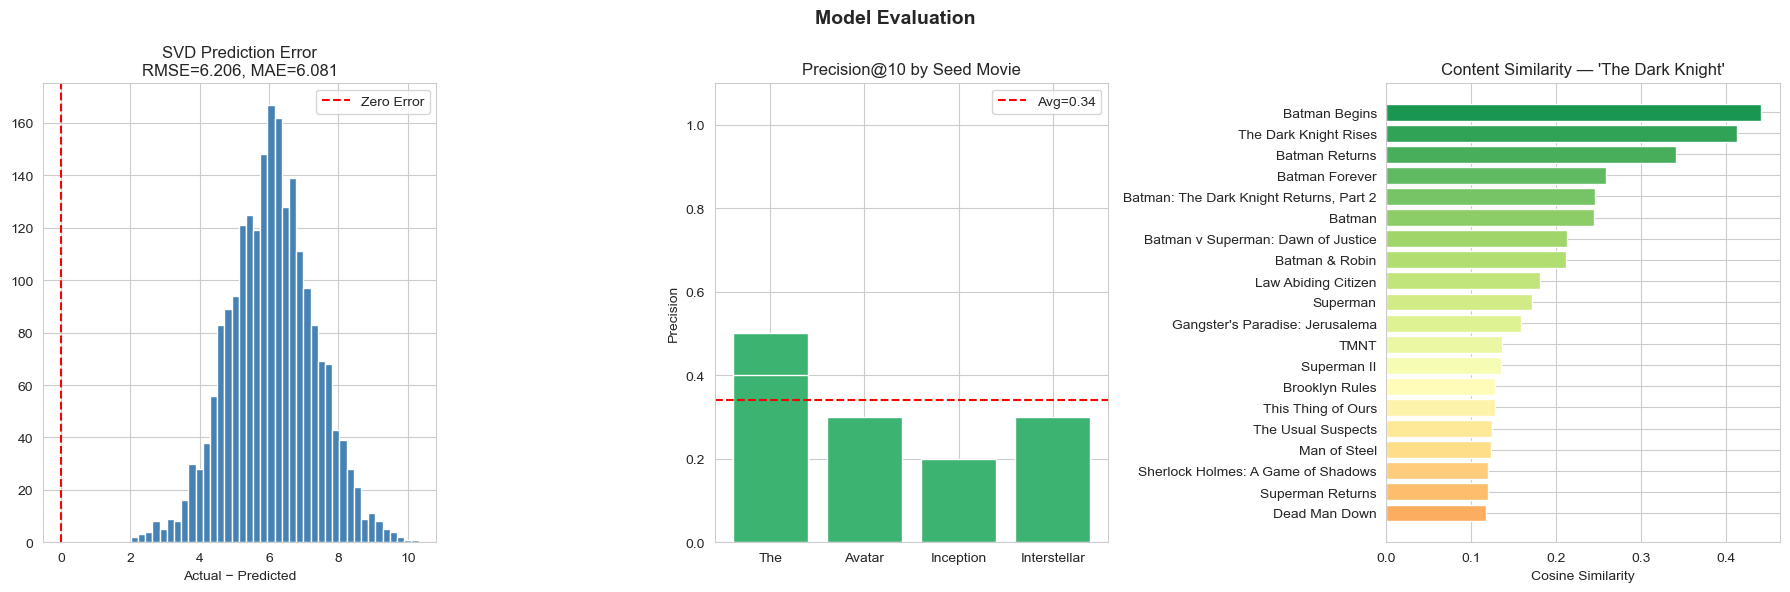

✅ Evaluation plots saved!


In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Evaluation', fontsize=14, fontweight='bold')

# 1. Error histogram
axes[0].hist(errors, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', label='Zero Error')
axes[0].set_title(f'SVD Prediction Error\nRMSE={rmse:.3f}, MAE={mae:.3f}')
axes[0].set_xlabel('Actual − Predicted')
axes[0].legend()

# 2. Precision@K bar chart
axes[1].bar([t.split()[0] for t in test_titles], p_at_k,
             color='mediumseagreen', edgecolor='white')
axes[1].axhline(np.mean(p_at_k), color='red', linestyle='--', label=f'Avg={np.mean(p_at_k):.2f}')
axes[1].set_title('Precision@10 by Seed Movie')
axes[1].set_ylabel('Precision')
axes[1].set_ylim(0, 1.1)
axes[1].legend()

# 3. Similarity score distribution for Dark Knight
dk_recs = content_recommend('The Dark Knight', n=20)
if dk_recs is not None:
    axes[2].barh(dk_recs['title'][::-1], dk_recs['similarity'][::-1],
                 color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(dk_recs))))
    axes[2].set_title("Content Similarity — 'The Dark Knight'")
    axes[2].set_xlabel('Cosine Similarity')

plt.tight_layout()
plt.savefig('evaluation_tmdb.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Evaluation plots saved!")

In [49]:
# UNIFIED RECOMMEND FUNCTION

In [52]:
def recommend(title=None, user_id=None, genre=None, method='content', n=10):
    """
    
      UNIFIED MOVIE RECOMMENDATION INTERFACE
    
    Parameters
    ----------
    title   : str  — movie title for content/hybrid
    user_id : int  — user ID for collaborative/hybrid
    genre   : str  — genre name for genre-based
    method  : str  — 'content' | 'collaborative' | 'hybrid' | 'genre' | 'top'
    n       : int  — number of results
    """
    labels = {
        'content'      : ' CONTENT-BASED FILTERING',
        'collaborative': ' COLLABORATIVE FILTERING',
        'hybrid'       : ' HYBRID RECOMMENDATION',
        'genre'        : '  GENRE-BASED RECOMMENDATION',
        'top'          : ' TOP RATED MOVIES'
    }
    print("\n" + "━"*65)
    print(f"  {labels.get(method, 'RECOMMENDATION')}")
    if title:   print(f"  Seed Movie : {title}")
    if user_id: print(f"  User ID    : #{user_id}")
    if genre:   print(f"  Genre      : {genre}")
    print(f"  Top        : {n} results")
    print("━"*65)

    if method == 'content':
        result = content_recommend(title, n)
    elif method == 'collaborative':
        result = collaborative_recommend(user_id, n)
    elif method == 'hybrid':
        result = hybrid_recommend(user_id, title, n)
    elif method == 'genre':
        result = recommend_by_genre(genre, n)
    elif method == 'top':
        result = df_clean.nlargest(n, 'weighted_rating')[[
            'title', 'year', 'vote_average', 'vote_count', 'weighted_rating'
        ]].reset_index(drop=True)
        result.index += 1
    else:
        print("❌ method must be: content | collaborative | hybrid | genre | top")
        return

    print(result.to_string())
    return result


#  FINAL DEMO 

print("  FINAL DEMO — ALL RECOMMENDATION METHODS")


recommend(title='Interstellar',         method='content',       n=8)
recommend(user_id=99,                   method='collaborative', n=8)
recommend(title='The Avengers', user_id=15, method='hybrid',   n=8)
recommend(genre='Thriller',             method='genre',         n=8)
recommend(                              method='top',           n=10)

  FINAL DEMO — ALL RECOMMENDATION METHODS

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   CONTENT-BASED FILTERING
  Seed Movie : Interstellar
  Top        : 8 results
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                        title    year          director  vote_average  weighted_rating  similarity                             genres
1              Silent Running  1972.0  Douglas Trumbull           6.3         6.140701      0.2966  Adventure, Drama, Science Fiction
2                   Apollo 13  1995.0        Ron Howard           7.3         6.978097      0.2130                              Drama
3            Midnight Special  2016.0      Jeff Nichols           6.2         6.150864      0.2084  Adventure, Drama, Science Fiction
4                 The Martian  2015.0      Ridley Scott           7.6         7.488387      0.2006  Drama, Adventure, Science Fiction
5  Stargate: The Ark of Truth  2008.0  Robert C. Cooper           6.9      

,title,year,vote_average,vote_count,weighted_rating
1,The Shawshank Redemption,1994.0,8.5,8205,8.340775
2,The Godfather,1972.0,8.4,5893,8.192887
3,Fight Club,1999.0,8.3,9413,8.171648
4,Pulp Fiction,1994.0,8.3,8428,8.157615
5,The Dark Knight,2008.0,8.2,12002,8.102674
6,Forrest Gump,1994.0,8.2,7927,8.056059
7,Schindler's List,1993.0,8.3,4329,8.038748
8,Whiplash,2014.0,8.3,4254,8.034695
9,Inception,2010.0,8.1,13752,8.018611
10,The Empire Strikes Back,1980.0,8.2,5879,8.010426


In [53]:
# FINAL SUMMARY

In [56]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║       🎬 MOVIE RECOMMENDATION SYSTEM — PROJECT SUMMARY           ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Dataset   : TMDB 5000 Movies (Kaggle)                          ║
║  Language  : Python 3                                           ║
║  Libraries : Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn   ║
║                                                                  ║
║  METHODS IMPLEMENTED:                                           ║
║  ① Content-Based  — TF-IDF + Cosine Similarity                  ║
║  ② Collaborative  — SVD Matrix Factorization                    ║
║  ③ Hybrid         — Weighted CB + CF combination                ║
║  ④ Genre-Based    — Weighted Rating filter by genre             ║
║  ⑤ Top Rated      — IMDB-style weighted rating formula          ║
║                                                                  ║
║  EVALUATION METRICS:                                            ║
║  • RMSE / MAE    (Collaborative Filtering)                      ║
║  • Precision@K   (Content-Based Filtering)                      ║
║                                                                  ║
║  FUTURE SCOPE:                                                  ║
║  • Neural Collaborative Filtering (NCF)                         ║
║  • BERT-based semantic similarity                               ║
║  • Flask/Streamlit web application                              ║
║  • Real-time recommendations via TMDB API                       ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║       🎬 MOVIE RECOMMENDATION SYSTEM — PROJECT SUMMARY           ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Dataset   : TMDB 5000 Movies (Kaggle)                          ║
║  Language  : Python 3                                           ║
║  Libraries : Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn   ║
║                                                                  ║
║  METHODS IMPLEMENTED:                                           ║
║  ① Content-Based  — TF-IDF + Cosine Similarity                  ║
║  ② Collaborative  — SVD Matrix Factorization                    ║
║  ③ Hybrid         — Weighted CB + CF combination                ║
║  ④ Genre-Based    — Weighted Rating filter by genre             ║
║  ⑤ Top Rated      — IMDB-style weighted rating formula          ║
║                                          